Exercise 1


Questions a) b) and c)

In [8]:
import matplotlib.pyplot as plt

In [ ]:
# Erlang-B function from Step (a)
def erlang_b(A, C):
    inv_B = 1.0
    for k in range(1, C + 1):
        inv_B = 1.0 + inv_B * (k / A)
    return 1.0 / inv_B 

In [ ]:
# Parameters
A = 25
channels = list(range(15, 46)) 
probabilities = [erlang_b(A, c) for c in channels]

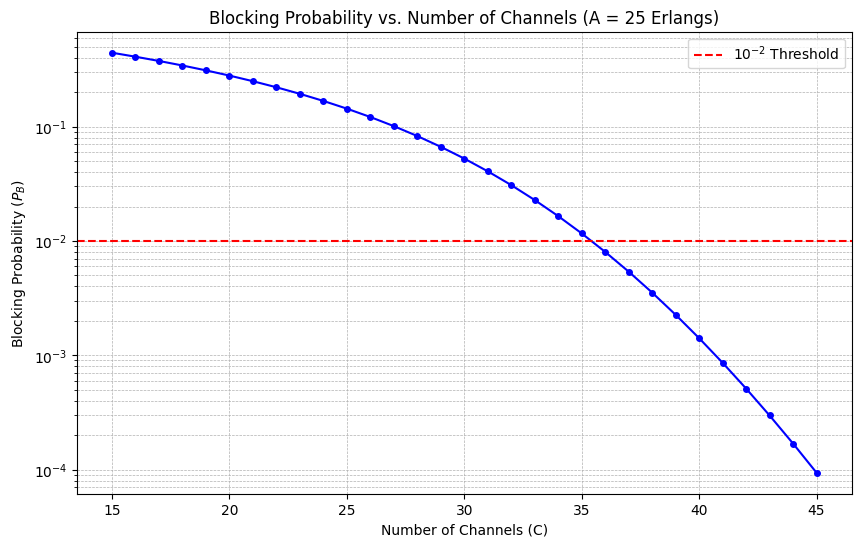

In [11]:
# Plotting the curve
plt.figure(figsize=(10, 6))
plt.plot(channels, probabilities, marker='o', markersize=4, linestyle='-', color='b')

# Add a horizontal line for the 1% threshold
plt.axhline(y=0.01, color='red', linestyle='--', label='$10^{-2}$ Threshold')

# Formatting the plot
plt.yscale('log') 
plt.title('Blocking Probability vs. Number of Channels (A = 25 Erlangs)')
plt.xlabel('Number of Channels (C)')
plt.ylabel('Blocking Probability ($P_B$)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()

In [ ]:
# Display the plot
plt.show()

We can see that after 36 Channels we have a blocking probability inferior to $10^{-2}$. We can see the graph starts very high and with each new channel it starts going down, having more space between two points the longer we go. starting nearly at 0 with 1 channel and going all the way to $10^{-4}$ with 45 channels

Question d)

In [14]:
A = 35
channels = list(range(20, 56)) 
probabilities = [erlang_b(A, c) for c in channels]

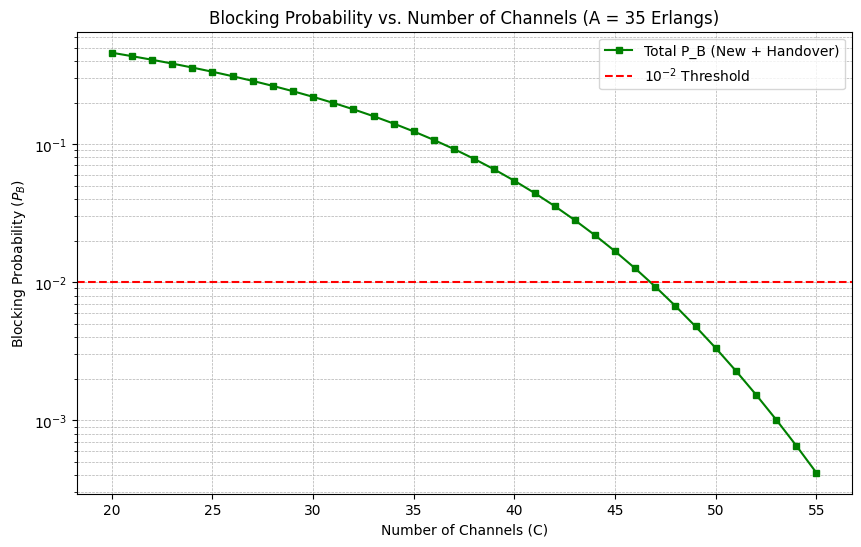

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(channels, probabilities, marker='s', markersize=4, linestyle='-', color='g', label='Total P_B (New + Handover)')

# Add a horizontal line for the 1% threshold
plt.axhline(y=0.01, color='red', linestyle='--', label='$10^{-2}$ Threshold')

# Formatting the plot
plt.yscale('log') 
plt.title('Blocking Probability vs. Number of Channels (A = 35 Erlangs)')
plt.xlabel('Number of Channels (C)')
plt.ylabel('Blocking Probability ($P_B$)')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()


In [ ]:
# Display the plot
plt.show() 

Question g)

[Example] When C1 = 30:
Blocking Prob (New Calls): 0.292433
Dropping Prob (Handover Calls): 0.000001


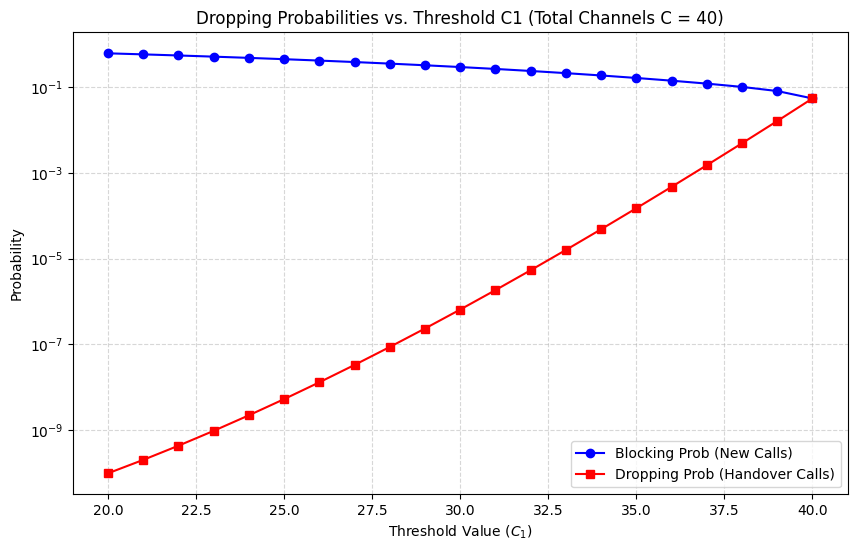

In [ ]:
import matplotlib.pyplot as plt

def admission_control_probs(lambda1, lambda2, mu, C, C1):
    #Calculate probabilities for the admission control strategy with threshold C1.
    A1 = lambda1 / mu  # Traffic load for new calls
    A2 = lambda2 / mu  # Traffic load for handover calls
    A_total = A1 + A2  # Total traffic load
    
    # Calculate unnormalized probability terms (using Markov Chain balance equations)
    terms = [0] * (C + 1)
    terms[0] = 1.0  # Assume initial state probability is 1 for easier calculation
    
    for k in range(1, C + 1):
        if k <= C1:
            # When used channels <= C1, accept both call types 
            # (arrival rate is lambda1 + lambda2)
            terms[k] = terms[k-1] * A_total / k
        else:
            # When used channels > C1, accept ONLY handover calls 
            # (arrival rate is lambda2)
            terms[k] = terms[k-1] * A2 / k
            
    # Normalize to get the true steady-state probabilities P_k
    sum_terms = sum(terms)
    P = [t / sum_terms for t in terms]
    
    #Calculate dropping/blocking probabilities for both call types
    
    #Blocking prob for new calls: 
    #New calls are rejected if used channels >= C1 (sum probabilities from C1 to C)
    P_block_new = sum(P[C1 : C + 1])
    
    #Dropping prob for handover calls: 
    #Handover calls are only rejected if all C channels are full (State C)
    P_drop_ho = P[C]
    
    return P_block_new, P_drop_ho

# Given conditions from the exercise
lambda1 = 5      # Arrival rate for new calls: 5 calls/min
lambda2 = 2      # Arrival rate for handover calls: 2 calls/min
mu = 1 / 5       # Service rate: 1/5 calls/min
C = 40           # Total number of channels is fixed at 40

# Prepare data for plotting (C1 varies from 20 to 40)
C1_values = list(range(20, 41))
prob_new_list = []
prob_ho_list = []

# Loop to calculate probabilities for each threshold value
for c1 in C1_values:
    p_new, p_ho = admission_control_probs(lambda1, lambda2, mu, C, c1)
    prob_new_list.append(p_new)
    prob_ho_list.append(p_ho)

# Print specific values when C1=30 for reference
demo_c1 = 30
print(f"[Example] When C1 = {demo_c1}:")
print(f"Blocking Prob (New Calls): {prob_new_list[demo_c1 - 20]:.6f}")
print(f"Dropping Prob (Handover Calls): {prob_ho_list[demo_c1 - 20]:.6f}")

# Plot the curves (fulfills the requirement for question h)
plt.figure(figsize=(10, 6))
plt.plot(C1_values, prob_new_list, marker='o', linestyle='-', color='blue', label='Blocking Prob (New Calls)')
plt.plot(C1_values, prob_ho_list, marker='s', linestyle='-', color='red', label='Dropping Prob (Handover Calls)')

# Set the title and axis labels
plt.title('Dropping Probabilities vs. Threshold C1 (Total Channels C = 40)')
plt.xlabel('Threshold Value ($C_1$)')
plt.ylabel('Probability')

# Use logarithmic scale to better visualize extreme probability variations
plt.yscale('log')  
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

Question h)

When the threshold C1 is low (e.g., C1 = 20), a large number of channels are exclusively reserved for handover calls. Consequently, the dropping probability for handover calls (red curve) is extremely low, but it comes at the severe cost of a very high blocking probability for new calls (blue curve). 
As C1 increases towards 40, the system reserves fewer channels. The blocking probability for new calls improves significantly, while the dropping probability for handover calls degrades.
When C1 = 40, the admission control is effectively disabled, and both curves merge, treating both types of calls equally. Therefore, the optimal value for C1 depends on the exact Quality of Service (QoS) requirements set by the network operator for both call types.